# Week 3: Tumor selectivity and safety

Takes Week 2's biology-checked shortlist (`depmap_tnbc_shortlist_v2.csv`,
40 genes) and asks two more questions per gene, per the project plan:

1. **Tumor selectivity:** is the gene actually *overexpressed* in real TNBC
   tumors relative to normal tissue -- essentiality alone doesn't make a
   good drug target if the gene isn't also elevated in the tumor.
2. **Safety:** is the gene also highly expressed in critical normal
   tissues (heart, liver, bone marrow) where hitting it with a drug would
   likely cause dose-limiting toxicity before it could work on the tumor?


In [1]:
# Load the Week 2 shortlist plus TCGA expression and GTEx median-TPM data
import sys, re
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from data_utils import load_tcga_expression, load_gtex_median_tpm

shortlist = pd.read_csv("../data/processed/depmap_tnbc_shortlist_v2.csv")
print(f"{len(shortlist)} genes carried over from Week 2")

expr = load_tcga_expression()
gtex = load_gtex_median_tpm()


40 genes carried over from Week 2


## Resolving the open "TCGA normal vs. GTEx baseline" decision

This was flagged as an open decision back in Week 0/1 -- turns out it isn't
really an either/or choice once the two questions above are separated:

- **Tumor selectivity** needs the *same tissue type*, ideally the *same
  study/pipeline*, so the comparison isn't confounded by batch effects
  between different sequencing centers/protocols. TCGA-BRCA's own 112
  matched-normal breast samples (sample-type code `11`) are the right
  baseline for this.
- **Safety** needs breadth across *many different organs* -- TCGA-BRCA
  only has breast tissue, so it can't answer "is this gene critical in the
  heart" at all. GTEx (68 tissues, including heart/liver/blood) is the
  only dataset that can.

So both get used, for genuinely different questions, rather than picking
one as "the" normal baseline.


In [2]:
# Split TCGA-BRCA samples into primary tumor vs. matched-normal breast, by their sample-type barcode
tumor_cols = [c for c in expr.columns if c.split("-")[3].startswith("01")]
normal_cols = [c for c in expr.columns if c.split("-")[3].startswith("11")]
print(f"TCGA-BRCA: {len(tumor_cols)} tumor samples, {len(normal_cols)} matched-normal breast samples")


TCGA-BRCA: 1093 tumor samples, 112 matched-normal breast samples


## Tumor vs. matched-normal breast expression

Matches genes by Entrez ID rather than symbol, same fix as Week 2 (this
2016-vintage TCGA file's gene symbols have drifted from DepMap's current
ones for a meaningful number of genes).


In [3]:
# For each shortlisted gene, compute tumor-vs-normal-breast log2 fold change and significance (matched by Entrez ID)
raw_cols = pd.read_csv("../data/raw/depmap/CRISPR Gene Effect.csv", nrows=0).columns[1:]
symbol_to_entrez = {}
for col in raw_cols:
    m = re.match(r"^(.*) \((\d+)\)$", col)
    symbol_to_entrez[m.group(1)] = m.group(2)

entrez_to_rows = {}
for idx in expr.index:
    parts = idx.split("|")
    if len(parts) == 2:
        entrez_to_rows.setdefault(parts[1], []).append(idx)

records = []
for gene in shortlist["gene"]:
    entrez = symbol_to_entrez.get(gene)
    exp_rows = entrez_to_rows.get(entrez) if entrez else None
    if not exp_rows:
        records.append((gene, np.nan, np.nan, np.nan, np.nan))
        continue
    tumor_vals = np.log2(expr.loc[exp_rows, tumor_cols].to_numpy().flatten().astype(float) + 1)
    normal_vals = np.log2(expr.loc[exp_rows, normal_cols].to_numpy().flatten().astype(float) + 1)
    log2fc = np.median(tumor_vals) - np.median(normal_vals)
    _, p = stats.mannwhitneyu(tumor_vals, normal_vals, alternative="two-sided")
    records.append((gene, np.median(tumor_vals), np.median(normal_vals), log2fc, p))

tumor_df = pd.DataFrame(
    records,
    columns=["gene", "median_log2_tumor", "median_log2_normal_breast", "log2fc_tumor_vs_normal", "tumor_vs_normal_p"],
)
tumor_df["tumor_vs_normal_q"] = stats.false_discovery_control(tumor_df["tumor_vs_normal_p"].fillna(1), method="bh")
tumor_df.sort_values("log2fc_tumor_vs_normal", ascending=False).head(10)


,gene,median_log2_tumor,median_log2_normal_breast,log2fc_tumor_vs_normal,tumor_vs_normal_p,tumor_vs_normal_q
26,KIF2C,8.751954,5.404779,3.347175,1.665808e-59,3.331616e-58
11,IFI6,11.623368,9.303470,2.319898,1.512043e-37,6.720190e-37
16,CREB3L4,11.138040,9.668257,1.469783,5.464348e-34,1.987036e-33
10,H2AC6,10.753565,9.306451,1.447114,1.104951e-24,2.762377e-24
35,HPRT1,9.489806,8.605815,0.883991,8.097572e-42,4.627184e-41
29,BIRC7,1.566766,0.963721,0.603045,8.319554e-07,1.279931e-06
22,SH3BP5L,10.053054,9.472163,0.580890,3.853631e-34,1.541452e-33
9,LY6E,12.295337,11.761821,0.533516,3.840809e-08,6.145294e-08
14,APRT,10.431797,9.996352,0.435445,4.155504e-12,7.555461e-12
21,SIGLEC8,5.774908,5.353860,0.421048,8.658797e-04,1.049551e-03


## Safety check: expression in critical normal tissues

Per the project plan's own examples: **heart, liver, and bone marrow** are
the classic dose-limiting-toxicity organs to check. GTEx doesn't sample
bone marrow directly, so **Whole Blood** is used as the standard proxy
(same substitution commonly used in target-safety screening). Two heart
chambers and the whole liver panel are included rather than just one
column each, so a gene missed by one sub-tissue isn't wrongly cleared.


In [4]:
# For each shortlisted gene, find its highest expression across the critical safety tissues and bucket it into a flag
CRITICAL_TISSUES = ["Heart_Left_Ventricle", "Heart_Atrial_Appendage", "Liver", "Whole_Blood"]

def critical_tissue_max(gene):
    row = gtex[gtex["Description"] == gene]
    if len(row) == 0:
        return np.nan
    return row[CRITICAL_TISSUES].to_numpy().flatten().astype(float).max()

safety_df = pd.DataFrame({
    "gene": shortlist["gene"],
    "gtex_critical_tissue_max_tpm": shortlist["gene"].apply(critical_tissue_max),
})

# TPM thresholds are a judgment call, documented here rather than left implicit:
# <5 negligible, 5-20 moderate (some caution), >20 high (real caution flag).
def flag(tpm):
    if pd.isna(tpm):
        return "unknown"
    if tpm > 20:
        return "high"
    if tpm > 5:
        return "moderate"
    return "low"

safety_df["safety_flag"] = safety_df["gtex_critical_tissue_max_tpm"].apply(flag)
safety_df["safety_flag"].value_counts()


safety_flag
high        16
moderate    12
low         12
Name: count, dtype: int64

## Combining into a final Week 3 table

Prioritizes genes that are tumor-overexpressed (`log2fc > 0`) with a low
critical-tissue safety flag, over genes that are merely essential.


In [5]:
# Merge essentiality, tumor-selectivity, and safety results into one final table, sorted by tumor overexpression
final = shortlist.merge(tumor_df, on="gene").merge(safety_df, on="gene")
final = final.sort_values(["log2fc_tumor_vs_normal"], ascending=False)
final.to_csv("../data/processed/depmap_tnbc_week3_final.csv", index=False)

cols = ["gene", "effect_size", "u_q", "log2fc_tumor_vs_normal", "tumor_vs_normal_q",
        "gtex_critical_tissue_max_tpm", "safety_flag"]
final[cols].head(15)


,gene,effect_size,u_q,log2fc_tumor_vs_normal,tumor_vs_normal_q,gtex_critical_tissue_max_tpm,safety_flag
26,KIF2C,-0.150047,0.166208,3.347175,3.331616e-58,1.803260,low
11,IFI6,-0.102545,0.122862,2.319898,6.720190e-37,71.658600,high
16,CREB3L4,-0.064794,0.148072,1.469783,1.987036e-33,7.132930,moderate
10,H2AC6,-0.109347,0.119712,1.447114,2.762377e-24,256.121000,high
35,HPRT1,-0.094389,0.177983,0.883991,4.627184e-41,16.067300,moderate
29,BIRC7,-0.065470,0.167824,0.603045,1.279931e-06,0.109287,low
22,SH3BP5L,-0.115976,0.166208,0.580890,1.541452e-33,37.550600,high
9,LY6E,-0.123067,0.117419,0.533516,6.145294e-08,175.538000,high
14,APRT,-0.113586,0.148072,0.435445,7.555461e-12,126.367000,high
21,SIGLEC8,-0.081399,0.165360,0.421048,1.049551e-03,0.138811,low


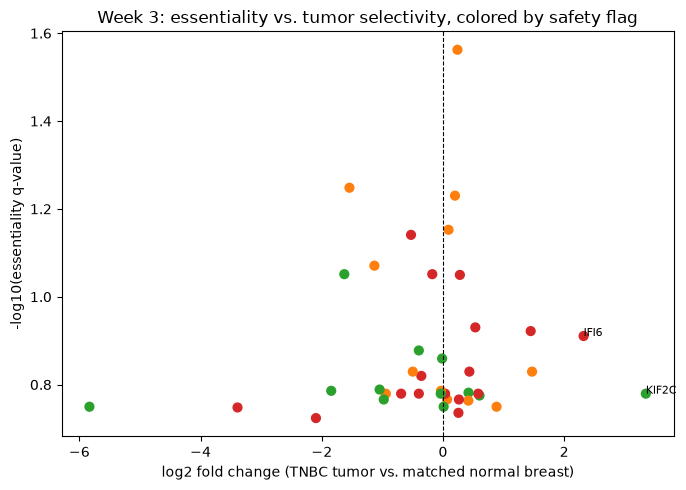

In [6]:
# Plot essentiality vs. tumor selectivity, colored by safety flag, to see the tradeoffs at a glance
fig, ax = plt.subplots(figsize=(7, 5))
colors = final["safety_flag"].map({"low": "tab:green", "moderate": "tab:orange", "high": "tab:red", "unknown": "gray"})
ax.scatter(final["log2fc_tumor_vs_normal"], -np.log10(final["u_q"]), c=colors, s=40)
for _, row in final.iterrows():
    if row["log2fc_tumor_vs_normal"] > 1.5 or row["gene"] == "KIF2C":
        ax.annotate(row["gene"], (row["log2fc_tumor_vs_normal"], -np.log10(row["u_q"])), fontsize=8)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("log2 fold change (TNBC tumor vs. matched normal breast)")
ax.set_ylabel("-log10(essentiality q-value)")
ax.set_title("Week 3: essentiality vs. tumor selectivity, colored by safety flag")
plt.tight_layout()
plt.show()


## The standout: KIF2C

`KIF2C` (kinesin family member 2C, a.k.a. MCAK) is the clearest win in
this list: **massively tumor-overexpressed** (log2 fold change +3.35,
q<1e-50 -- roughly a 10x increase over matched normal breast), **low
critical-tissue expression** (max 1.8 TPM across heart/liver/blood, safety
flag "low"), and selectively essential in TNBC per Week 2. Checked directly
against the literature (not memory): KIF2C/MCAK is independently and
extensively published as overexpressed in breast cancer -- including
ER-negative disease -- correlated with poor prognosis across multiple TCGA
cohort studies, and proposed as a prognostic biomarker. That's three
independent lines of evidence (DepMap essentiality, TCGA overexpression,
published literature) converging on the same gene -- exactly the kind of
multi-signal agreement this project's composite score (Week 4) is meant to
formalize, and a much stronger result than Week 2's essentiality signal
alone.

Week 2's literature check had called KIF2C "unconfirmed" -- that search was
specifically about a DepMap-CRISPR-essentiality angle, which genuinely
doesn't have a direct hit in the literature. The overexpression/prognosis
angle checked here is a different, and in this case much better supported,
question. Worth remembering: a "no hit" in one literature search doesn't
mean "no biology" -- it means that specific angle wasn't published, and a
different angle is worth trying before writing a candidate off.


## Safety concerns worth flagging explicitly

Several tumor-overexpressed genes carry a real safety caution:

- **`IFI6`** (log2fc +2.32) and **`LY6E`** (log2fc +0.53, Week 2's strongest
  literature-validated hit) both show high expression in critical tissues
  (71.7 and 175.5 TPM respectively) -- both are classic interferon-stimulated
  genes, broadly expressed in circulating immune cells, which plausibly
  explains the Whole Blood signal specifically rather than heart/liver.
  Doesn't rule either out (an antibody-drug approach might tolerate
  blood-compartment expression differently than a small molecule would),
  but it's a real caution to carry forward, not to quietly drop.
- **`H2AC6`** (a core histone gene) shows the highest critical-tissue value
  in the whole list (256 TPM) alongside strong tumor overexpression --
  consistent with histones being highly expressed in any proliferating
  tissue (including bone marrow/blood), which is exactly the kind of
  broad-proliferation signal rather than TNBC-specific biology this
  project's guardrails ask to watch for.
- **`SIGLEC8`**, on inspection, is a known eosinophil/mast-cell surface
  marker -- its apparent "tumor overexpression" more plausibly reflects
  immune cells infiltrating the bulk tumor sample than anything about the
  cancer cells themselves. A caution about bulk RNA-seq in general: it
  can't distinguish tumor-cell signal from infiltrating-immune-cell signal,
  and this project's mostly-epithelial candidate genes should be read with
  that limitation in mind.


## Week 3 outcome

`data/processed/depmap_tnbc_week3_final.csv` carries every Week 2 column
plus tumor-selectivity (log2fc, q-value) and the GTEx critical-tissue
safety flag -- the table Week 4's composite score will build on.
`KIF2C` is the standout candidate so far, with three independent lines of
evidence; a handful of others (`IFI6`, `LY6E`, `H2AC6`) carry real,
explicit safety caveats rather than being silently dropped or silently
trusted. Human Protein Atlas druggability annotation remains optional and
not yet added.
